<a href="https://colab.research.google.com/github/AreebaAmeen100/Parkinsons-ML-Project/blob/main/MileStone1_EDA_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import pandas as pd

#load the file
df = pd.read_csv('/content/parkinsons.data')

#check to see if loaded perfectly
print(f"Dataset loaded successfully! Total rows: {df.shape[0]}, Total columns: {df.shape[1]}")
df.head()

Dataset loaded successfully! Total rows: 195, Total columns: 24


,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


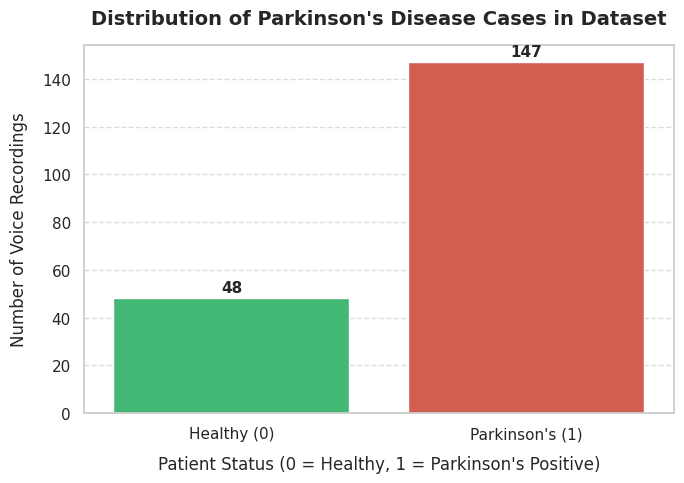

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid")
plt.figure(figsize=(7,5))

ax = sns.countplot(x='status', data=df, hue='status',
                   palette=['#2ecc71','#e74c3c'],
                   legend=False)

plt.title("Distribution of Parkinson's Disease Cases in Dataset",
          fontsize=14, fontweight='bold', pad=15)

plt.xlabel("Patient Status (0 = Healthy, 1 = Parkinson's Positive)",
           fontsize=12, labelpad=10)

plt.ylabel("Number of Voice Recordings",
           fontsize=12, labelpad=10)

plt.xticks(ticks=[0,1], labels=["Healthy (0)", "Parkinson's (1)"])

for p in ax.patches:
  ax.annotate(f'{int(p.get_height())}',
              (p.get_x() + p.get_width() / 2., p.get_height()),
              ha='center', va='center',
              xytext=(0,8),
              textcoords='offset points',
              fontsize=11, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

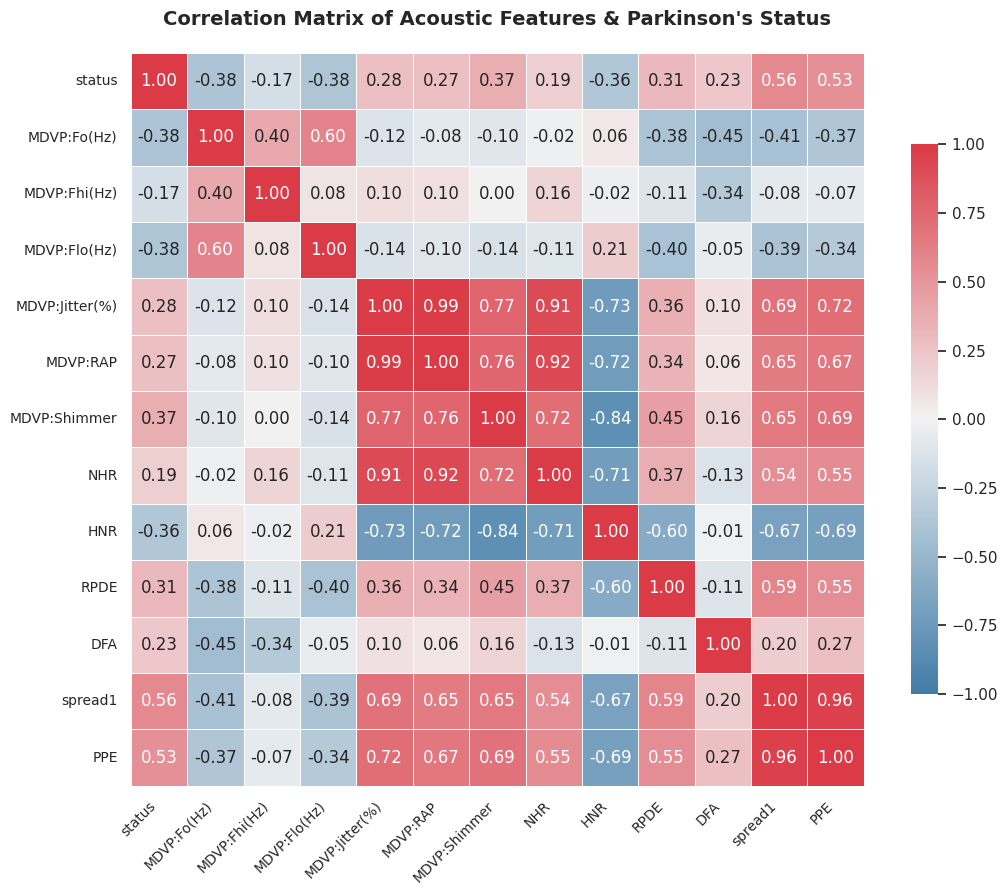

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#selecting specific columns so heatmap stays neat and easy to read
selected_features = [
    'status', 'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)',
    'MDVP:Jitter(%)', 'MDVP:RAP', 'MDVP:Shimmer',
    'NHR', 'HNR', 'RPDE', 'DFA', 'spread1', 'PPE'
]

#compute pearson correlation matrix
corr_matrix = df[selected_features].corr()

#setup the visual plot canvas
plt.figure(figsize=(11,9))

#generate clean diverging colormap (blue for negative, red for positive coorelation)
cmap = sns.diverging_palette(240, 10, as_cmap=True)

#draw matrix with numbers inside the squares
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap=cmap, vmin=-1, vmax=1,
            square=True, linewidths=.5, cbar_kws={"shrink": .75})

#title and formatting
plt.title("Correlation Matrix of Acoustic Features & Parkinson's Status", fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

/tmp/ipykernel_12814/3176644076.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Healthy (0)", "Parkinson's (1)"])
/tmp/ipykernel_12814/3176644076.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Healthy (0)", "Parkinson's (1)"])


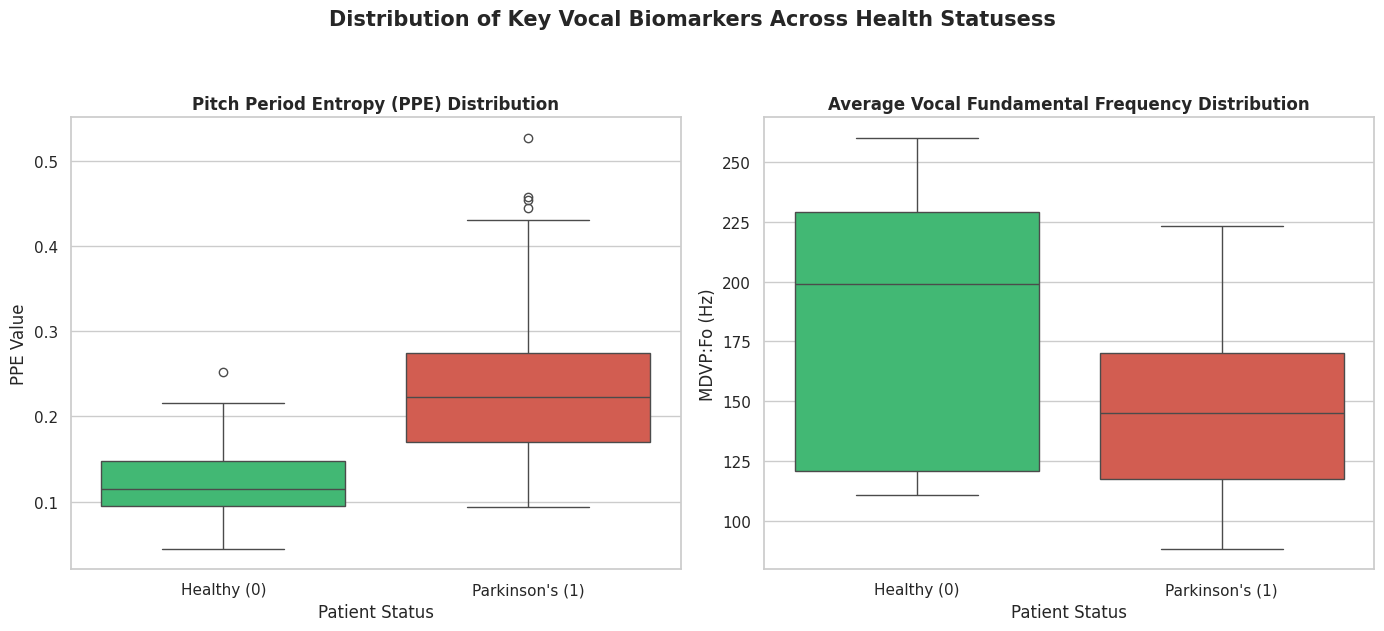

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

#theme setup
sns.set_theme(style="whitegrid")

#create subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(14,6))

#Graph 1 : PPE
sns.boxplot(
    ax=axes[0],
    x='status',
    y='PPE',
    data=df,
    hue='status',
    palette=['#2ecc71', '#e74c3c'],
    legend=False
)

axes[0].set_title("Pitch Period Entropy (PPE) Distribution",
                  fontsize=12, fontweight='bold')

axes[0].set_xlabel("Patient Status")
axes[0].set_ylabel("PPE Value")
axes[0].set_xticklabels(["Healthy (0)", "Parkinson's (1)"])

#Graph 2 : MDVP Fo
sns.boxplot(
    ax=axes[1],
    x='status',
    y='MDVP:Fo(Hz)',
    data=df,
    hue='status',
    palette=['#2ecc71', '#e74c3c'],
    legend=False
)

axes[1].set_title("Average Vocal Fundamental Frequency Distribution",
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel("Patient Status")
axes[1].set_ylabel("MDVP:Fo (Hz)")
axes[1].set_xticklabels(["Healthy (0)", "Parkinson's (1)"])

#overall title
plt.suptitle("Distribution of Key Vocal Biomarkers Across Health Statusess",
             fontsize=15, fontweight='bold', y=1.05)

plt.tight_layout()
plt.show()

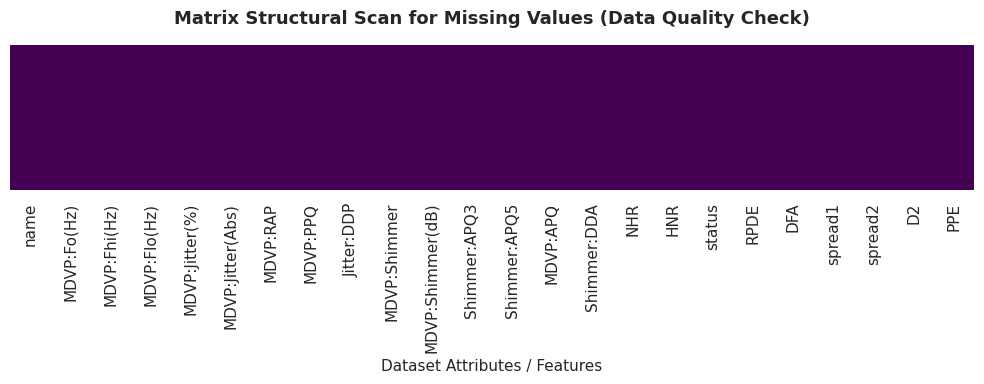

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,4))
#this checks for null values and plots them (they will appear as solid block if clean)
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')

plt.title("Matrix Structural Scan for Missing Values (Data Quality Check)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Dataset Attributes / Features", fontsize=11)
plt.tight_layout()
plt.show()

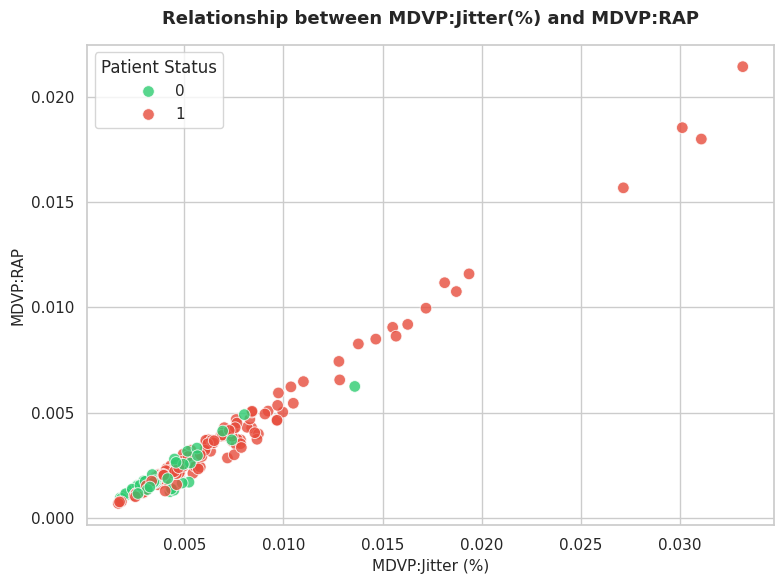

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='MDVP:Jitter(%)',
    y='MDVP:RAP',
    hue='status',
    palette=['#2ecc71', '#e74c3c'],
    alpha=0.8,
    s=70
)

plt.title("Relationship between MDVP:Jitter(%) and MDVP:RAP",
          fontsize=13, fontweight='bold', pad=15)

plt.xlabel("MDVP:Jitter (%)", fontsize=11)
plt.ylabel("MDVP:RAP", fontsize=11)

plt.legend(title="Patient Status")

plt.tight_layout()
plt.show()

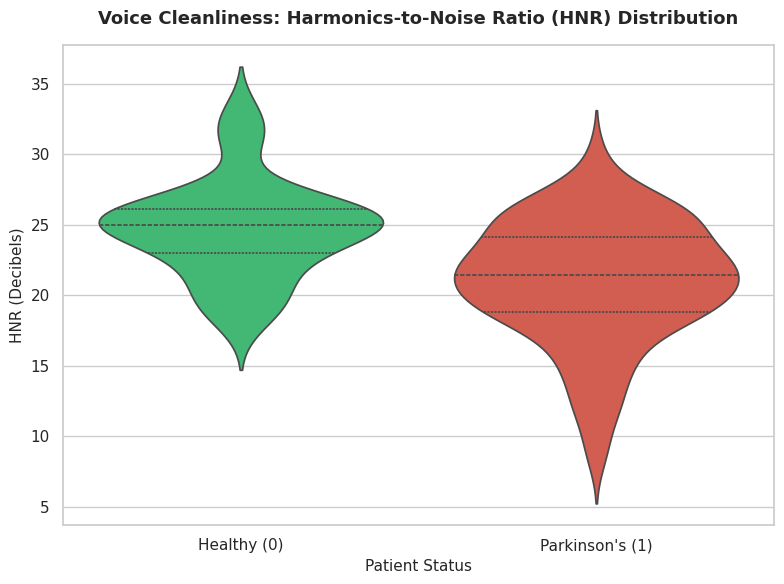

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.violinplot(
    x='status',
    y='HNR',
    data=df,
    hue='status',
    palette=['#2ecc71', '#e74c3c'],
    inner="quartile",
    legend=False
)

plt.title("Voice Cleanliness: Harmonics-to-Noise Ratio (HNR) Distribution",
          fontsize=13, fontweight='bold', pad=15)

plt.xlabel("Patient Status", fontsize=11)
plt.ylabel("HNR (Decibels)", fontsize=11)

plt.xticks(ticks=[0,1], labels=["Healthy (0)", "Parkinson's (1)"])

plt.tight_layout()
plt.show()